In [ ]:
%pip install numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

import multiprocessing
from multiprocessing import Pool

import yfinance as yf

In [ ]:
start = '2010-01-01'
end = '2024-12-31'

tickers = ['VNQ', 'SPY', 'GLD', 'BTC-USD']

benchmark_weights = np.array([0.1, 0.8, 0.05, 0.05, 0])

df = yf.download(tickers, start=start, end=end, interval="1mo")
df = df['Close']
df = df.dropna().copy()

/tmp/ipython-input-3100005276.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start, end=end, interval="1mo")
[*********************100%***********************]  4 of 4 completed


In [ ]:
df.head()

Ticker,BTC-USD,GLD,SPY,VNQ
Date,,,,
2014-09-01,386.944000,116.209999,162.879745,46.218307
2014-10-01,338.321014,112.660004,167.495010,51.283539
2014-11-01,378.046997,112.110001,172.096451,52.309330
2014-12-01,320.192993,113.580002,170.717743,52.588501
2015-01-01,217.464005,123.449997,166.573761,56.957664


In [ ]:
return_tickers = []
for ticker in tickers:
  rtick = f"{ticker}_return"
  df[rtick] = df[ticker].pct_change()
  return_tickers.append(rtick)

In [ ]:
# split into train and test
n_train = int(0.8 * len(df))
df_train = df.iloc[:n_train]
df_test = df.iloc[n_train:]

In [ ]:
# pre-compute returns
train_returns = df_train[return_tickers].dropna().to_numpy()
test_returns = df_test[return_tickers].dropna().to_numpy()

In [ ]:
# add a column of 0s for cash
z = np.zeros((train_returns.shape[0], 1))
train_returns = np.hstack((train_returns, z))

In [ ]:
z = np.zeros((test_returns.shape[0], 1))
test_returns = np.hstack((test_returns, z))

In [ ]:
def evolution_strategy(
    f,
    population_size,
    sigma,
    lr,
    initial_params,
    num_iters,
    pool):

  # assume initial params is a 1-D array
  num_params = len(initial_params)
  reward_per_iteration = np.zeros(num_iters)

  params = initial_params
  for t in range(num_iters):
    t0 = datetime.now()
    N = np.random.randn(population_size, num_params)

    ### fast way
    R = pool.map(f, [params + sigma*N[j] for j in range(population_size)])
    R = np.array(R)

    m = R.mean()
    s = R.std()
    if s == 0:
      # we can't apply the following equation
      print("Skipping")
      continue

    A = (R - m) / s

    reward_per_iteration[t] = m
    params = params + lr/(population_size*sigma) * np.dot(N.T, A)

    print("Iter:", t, "Avg Reward: %.3f" % m, "Max: %.3f" % R.max(), "Duration:", (datetime.now() - t0))

  return params, reward_per_iteration


In [ ]:
def softmax(a):
  c = np.max(a, axis=-1, keepdims=True)
  e = np.exp(a - c)
  return e / e.sum(axis=-1, keepdims=True)

In [ ]:
def sortino_ratio(returns, target=0):
  downside = returns[returns < target]
  downside_deviation = np.sqrt(np.mean((downside - target) ** 2)) \
    if len(downside) > 0 else 1e-8
  return (np.mean(returns) - target) / downside_deviation

In [ ]:
def reward_function(params, returns=train_returns, plot=False):
  weights = softmax(params)
  portfolio_returns = returns @ weights # (T, D) * (D, 1) = (T, 1)

  if plot:
    cumulative_gross_return = np.cumprod(portfolio_returns + 1)

    # benchmark returns
    benchmark_returns = returns @ benchmark_weights
    cumulative_benchmark_return = np.cumprod(benchmark_returns + 1)

    plt.plot(cumulative_benchmark_return, label='benchmark')
    plt.plot(cumulative_gross_return, label='portfolio')
    plt.legend()
    plt.title('Cumulative Gross Return')
    plt.show()

  return sortino_ratio(portfolio_returns)

Iter: 0 Avg Reward: 0.266 Max: 0.276 Duration: 0:00:00.005811
Iter: 1 Avg Reward: 0.302 Max: 0.314 Duration: 0:00:00.002916
Iter: 2 Avg Reward: 0.342 Max: 0.354 Duration: 0:00:00.002899
Iter: 3 Avg Reward: 0.385 Max: 0.397 Duration: 0:00:00.002670
Iter: 4 Avg Reward: 0.397 Max: 0.410 Duration: 0:00:00.003338
Iter: 5 Avg Reward: 0.410 Max: 0.417 Duration: 0:00:00.003217
Iter: 6 Avg Reward: 0.419 Max: 0.421 Duration: 0:00:00.003461
Iter: 7 Avg Reward: 0.421 Max: 0.422 Duration: 0:00:00.003288
Iter: 8 Avg Reward: 0.427 Max: 0.432 Duration: 0:00:00.002963
Iter: 9 Avg Reward: 0.432 Max: 0.434 Duration: 0:00:00.006117
Iter: 10 Avg Reward: 0.431 Max: 0.434 Duration: 0:00:00.002928
Iter: 11 Avg Reward: 0.429 Max: 0.435 Duration: 0:00:00.007943
Iter: 12 Avg Reward: 0.433 Max: 0.434 Duration: 0:00:00.004823
Iter: 13 Avg Reward: 0.432 Max: 0.434 Duration: 0:00:00.004918
Iter: 14 Avg Reward: 0.423 Max: 0.429 Duration: 0:00:00.009104
Iter: 15 Avg Reward: 0.422 Max: 0.429 Duration: 0:00:00.005295
It

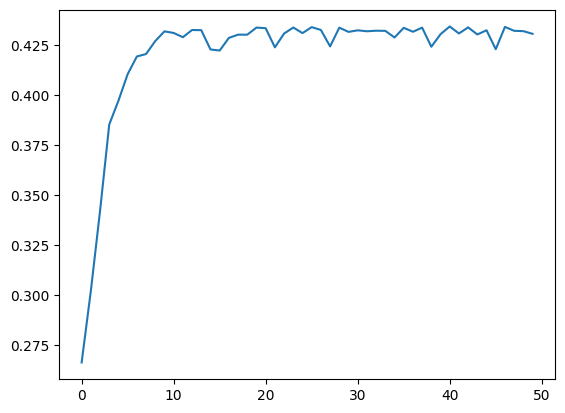

Best weights:
VNQ 0.021
SPY 0.126
GLD 0.554
BTC-USD 0.247
Cash 0.052


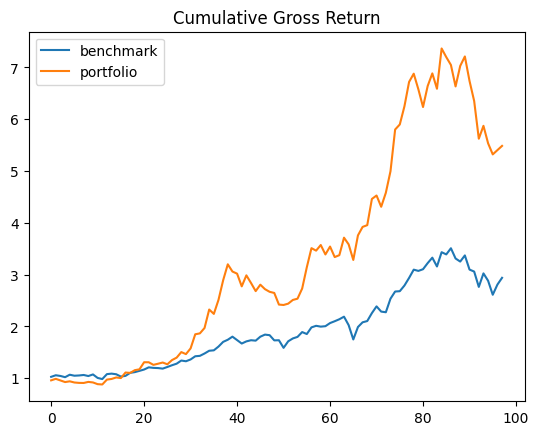

Sortino Ratio Train: 0.43551649954510857


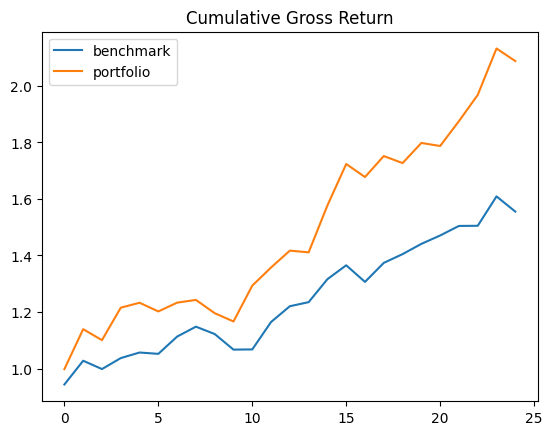

Sortino Ratio Test: 1.3636842118353378


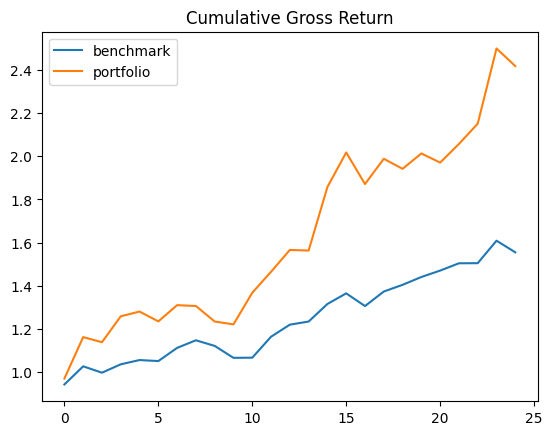

Sortino Ratio BTC: 1.1192883786474799
Sortino Ratio Benchmark: 0.49560506437444923


In [ ]:
if __name__ == '__main__':
  # thread pool for parallelization
  pool = Pool(4)

  # train and save
  params = np.random.randn(len(tickers) + 1)
  best_params, rewards = evolution_strategy(
    f=reward_function,
    population_size=30, # this gets > 2k
    # population_size=10,
    # sigma=0.1,
    sigma=0.05,
    # lr=0.03,
    lr=0.02,
    initial_params=params,
    num_iters=50,
    pool=pool,
  )

  # plot the rewards per iteration
  plt.plot(rewards)
  plt.show()

  print("Best weights:")
  best_weights = softmax(best_params)
  for w, t in zip(best_weights, tickers + ['Cash']):
    print(f"{t} {w:.3f}")

  # plot portfolio performance over time train
  sr = reward_function(best_params, returns=train_returns, plot=True)
  print("Sortino Ratio Train:", sr)

  # plot portfolio performance over time test
  sr = reward_function(best_params, returns=test_returns, plot=True)
  print("Sortino Ratio Test:", sr)

  # sortino ratio for all BTC
  all_btc = np.array([0, 0, 0, 1, 0])
  sr = reward_function(all_btc, returns=test_returns, plot=True)
  print("Sortino Ratio BTC:", sr)

  # sortino ratio for benchmark
  portfolio_returns = test_returns @ benchmark_weights
  sr = sortino_ratio(portfolio_returns)
  print("Sortino Ratio Benchmark:", sr)

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=8fP_8gnYambvgyDFSyTaIA&n=ES+Static+Portfolio)